# Project: Amazon Product Recommendation System

Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

# 1. Introduction

## Context

E-commerce websites like Amazon, Flipkart uses different recommendation models to provide personalized suggestions to different users. For example, one of the recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

## Objective

Build a recommendation system to **recommend top n products** to customers based on their previous ratings for other products.

# 2. Dataset

The Amazon dataset contains the following attributes:

* userId: Every user identified with a unique id
* productId: Every product identified with a unique id
* Rating: The rating of the corresponding product by the corresponding user
* timestamp: Time of the rating. We will not use this column to solve the current problem

In [2]:
!pip install surprise

## Importing the necessary libraries and overview of the dataset

In [3]:
import warnings                                 # Used to ignore the warning given as output of the code
warnings.filterwarnings('ignore')

import numpy as np                              # Basic libraries of python for numeric and dataframe computations
import pandas as pd

import matplotlib.pyplot as plt                 # Basic library for data visualization
import seaborn as sns                           # Slightly advanced library for data visualization

from collections import defaultdict             # A dictionary output that does not raise a key error

from sklearn.metrics import mean_squared_error  # A performance metrics in sklearn

### Loading the data

In [4]:
# Import the dataset
df = pd.read_csv('./data/ratings_Electronics.csv', header = None) # There are no headers in the data file

df.columns = ['user_id', 'prod_id', 'rating', 'timestamp'] # Adding column names

df = df.drop('timestamp', axis = 1) # Dropping timestamp since it's not useful for the recommendation system

df_copy = df.copy(deep = True) # Copying the data to another DataFrame


In [5]:
df_copy.shape

(7824482, 3)

**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [6]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:        
        ratings_count[user] += 1
  
    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1


In [7]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [8]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:
    
    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1
    
    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1    

In [9]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [10]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0


## Exploratory Data Analysis

### Shape of the data

In [11]:
# Check the number of rows and columns and provide observations
rows, columns = df_final.shape
print("No of rows: ", rows) 
print("No of columns: ", columns) 

No of rows:  65290
No of columns:  3


**Observations:**

* As we can see, the original dataset was reduced considerably from 7,824,482 rows to 65,290 since we only chose those users who have at least 50 ratings and those items which have at least 5 ratings
* Now with less data it will be easier to compute the recommendation systems
* Also, we have dropped timestamp column because we will not use it to solve the current problem

### Data types

In [12]:
# Check Data types and provide observations
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65290 entries, 1310 to 7824427
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  65290 non-null  object 
 1   prod_id  65290 non-null  object 
 2   rating   65290 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.0+ MB


In [13]:
df_final.rating.unique()

array([5., 1., 3., 4., 2.])

**Observations:**

* All columns have 65,290 observations
* None of the columns have missing or null values
* user_id and prod id are in string format
* rating is the only numerical column (float). It takes values from 1 to 5

### Checking for missing values

In [14]:
# Check for missing values present and provide observations
df_final.isnull().sum()

user_id    0
prod_id    0
rating     0
dtype: int64

**Observations:**

* Neither column has null or missing values, so we will not worried about to handle these cases

### Summary Statistics

In [15]:
# Summary statistics of 'rating' variable and provide observations
df_final['rating'].describe().T

count    65290.000000
mean         4.294808
std          0.988915
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

**Observations:**

* On average, users that rate a product tend to give a good score of 4
* The minimum value of a rating is 1 and the maximum is 5
* The data seems to be skewed towards 5

### Checking the rating distribution

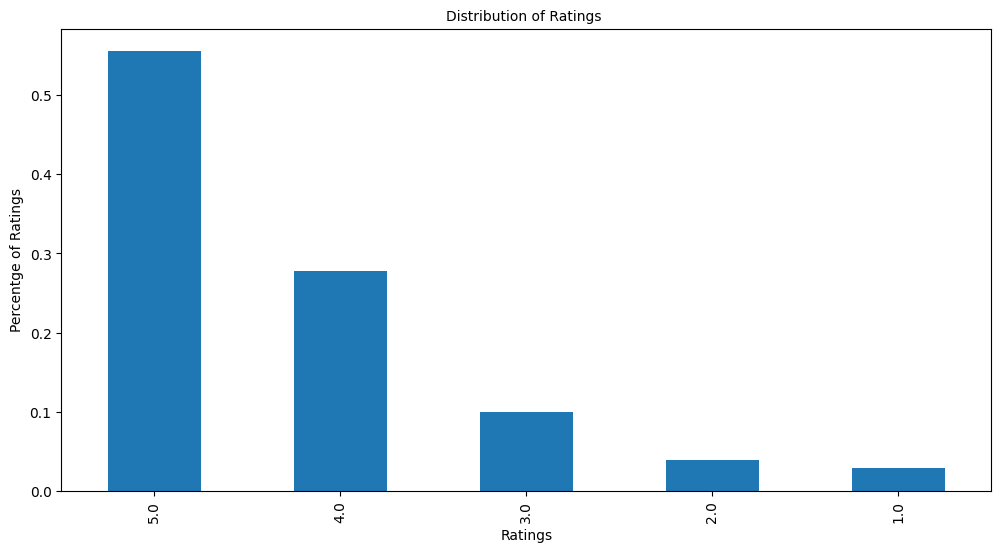

In [16]:
# Create the bar plot and provide observations
plt.figure(figsize = (12, 6))

df_final['rating'].value_counts(1).plot(kind = 'bar')

plt.title("Distribution of Ratings ", fontsize = 10)

# Set the xlabel of the plot
plt.xlabel("Ratings", fontsize = 10)

# Set the ylabel of the plot
plt.ylabel("Percentge of Ratings", fontsize = 10)

plt.show()

**Observations:**

* The data seems to be **highly skewed** towards Rating **'4' and '5'**. Rating '5' is the highest in the count.
* We can see very few people are giving ratings between 1 to 3. It shows people tend to not give a rating for items that they don't like, so they just skip rating. 

### Checking the number of unique users and items in the dataset

In [17]:
# Number of unique user id and product id in the raw data
print('Number of unique USERS in Raw data = ', df['user_id'].nunique())
print('Number of unique ITEMS in Raw data = ', df['prod_id'].nunique())

Number of unique USERS in Raw data =  1540
Number of unique ITEMS in Raw data =  48190


* There are **1,540 unique users and 48,190 products** in the original dataset (raw data).

### Users with the most number of ratings

In [18]:
# Top 10 users based on the number of ratings
most_rated = df_final.groupby('user_id').size().sort_values(ascending = False)[:10]
most_rated

user_id
ADLVFFE4VBT8      295
A3OXHLG6DIBRW8    230
A1ODOGXEYECQQ8    217
A36K2N527TXXJN    212
A25C2M3QF9G7OQ    203
A680RUE1FDO8B     196
A22CW0ZHY3NJH8    193
A1UQBFCERIP7VJ    193
AWPODHOB4GFWL     184
A3LGT6UZL99IW1    179
dtype: int64

* The highest number of **ratings by a user is 295** which is far from the actual number of products present in the data. We can build a recommendation system to recommend products to users which they have not interacted with.

### Data Preparation

In [19]:
# Check the number of unique USERS and PRODUCTS in the final data and provide observations
print('The number of observations in the final data = ', len(df_final))

print('Number of unique USERS in the final data = ', df_final['user_id'].nunique())

print('Number of unique PRODUCTS in the final data = ', df_final['prod_id'].nunique())

The number of observations in the final data =  65290
Number of unique USERS in the final data =  1540
Number of unique PRODUCTS in the final data =  5689


**Observations:**

Since we reduced the number of users with those that have at least 50 ratings and products that have at least 5 ratings.

* The number of users were not reduced.
* The number of products have been reduced considerably decreasing from 48,190 to 5,689. It means that many products don't have more than 4 reviews.

Now that we have explored and prepared the data, let's build the first recommendation system.

# 3. Baseline Models

## Model 1: Rank Based Recommendation System

In [20]:
df_final.head()

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0


In [21]:
print(df_final['rating'].dtype)
df_final['rating'] = pd.to_numeric(df_final['rating'])

float64


In [22]:
# Calculate the average rating for each product 
average_rating = df_final.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
count_rating = df_final.groupby('prod_id').count()['rating']

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})

# Sort the dataframe by average of ratings in the descending order
final_rating = final_rating.sort_values(by = 'avg_rating',ascending = False)

# See the first five records of the "final_rating" dataset
final_rating.head()

,avg_rating,rating_count
prod_id,,
B00LGQ6HL8,5.0,5
B003DZJQQI,5.0,14
B005FDXF2C,5.0,7
B00I6CVPVC,5.0,7
B00B9KOCYA,5.0,8


In [23]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions

def top_n_products(final_rating, n, min_interaction):
    
    # Finding products with minimum number of interactions
    recommendations = final_rating[final_rating['rating_count'] > min_interaction]
    
    # Sorting values with respect to average rating 
    recommendations = recommendations.sort_values(by = 'avg_rating', ascending = False)
    
    return recommendations.index[:n]

### Recommending top 5 products with 50 minimum interactions based on popularity


In [24]:
list(top_n_products(final_rating, 5, 50))

['B001TH7GUU', 'B003ES5ZUU', 'B0019EHU8G', 'B006W8U2MU', 'B000QUUFRW']

### Recommending top 5 products with 100 minimum interactions based on popularity

In [25]:
list(top_n_products(final_rating, 5, 100))

['B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B002V88HFE', 'B004CLYEDC']

We have recommended the **top 5** products by using the **popularity** recommendation system. Now, let's build a recommendation system using **collaborative filtering**.

## Model 2: Collaborative Filtering Recommendation System

In this type of recommendation system, we do not need any information about the users or items. We only need user item interaction data to build a collaborative recommendation system. For example:

1. **Ratings** provided by users. For example, ratings of books on goodread, movie ratings on imdb, etc.
2. **Likes** of users on different facebook posts, likes on youtube videos.
3. **Use/buying** of a product by users. For example, buying different items on e-commerce sites.
4. **Reading** of articles by readers on various blogs.

**Types of Collaborative Filtering:**

* Similarity/Neighborhood based
    * User-User Similarity Based
    * Item-Item similarity based
* Model based



### Building a baseline user-user similarity based recommendation system

* Below, we are building **similarity-based recommendation systems** using **cosine similarity** and using **KNN** to find **similar users** which are the nearest neighbor to the given user.
* We will be using a new library, called surprise, to build the remaining models. Let's first import the necessary classes and functions from this library.


In [26]:
!conda install -c conda-forge scikit-surprise -y

Retrieving notices: ...working... done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3/envs/dev

  added / updated specs:
    - scikit-surprise


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    openssl-3.6.3              |       hd24854e_0         3.0 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         3.0 MB

The following packages will be UPDATED:

  openssl                                  3.6.2-hd24854e_0 --> 3.6.3-hd24854e_0 



                                                                                
Preparing transaction: done
Verifying transaction: done
Executing transaction: done

Channel "pkgs/main" has the following notices:
  [info] -- Tue Jun  9 00:00:00 2026
  PyTorch 2.12 with CUDA suppo

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use Google Colab for this project.

For Google Colab just install this way: !pip install surprise


In [27]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating (here 3.5)** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.

**Recommended item**: An item that's **predicted rating is higher than the threshold (here 3.5) is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.

**False Negative (FN)**: It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP)**: It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall**: It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision**: It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### Precision@k, Recall@ k, and F1-score@k

**Precision@k** - It is the **fraction of recommended items that are relevant in top k predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.

**Recall@k** - It is the **fraction of relevant items that are recommended to the user in top k predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k** and **recall@k** both seem to be important then it is useful to use this metric because it is representative of both of them.

### Some useful functions

* Below function takes the **recommendation model** as input and gives the **precision@k**, **recall@k**, and **F1-score@k** for that model.
* To compute **precision** and **recall**, **top k** predictions are taken under consideration for each user.
* We will use the precision and recall to compute the F1-score.

In [28]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)
    
    # Making predictions on the test data
    predictions = model.test(testset)
    
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    
    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)
    
    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)
    
    accuracy.rmse(predictions)
    
    print('Precision: ', precision) # Command to print the overall precision
    
    print('Recall: ', recall) # Command to print the overall recall
    
    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

* To compute **precision and recall**, a **threshold of 3.5** and **k value of 10** is taken for the recommended and relevant ratings.
* In the present case, **precision and recall** both **need to be optimized** as the service provider would like to **minimize both the losses** discussed above. Hence, the correct performance measure is the **F_1 score.**

Below we are loading the rating dataset, which is a pandas DataFrame, into a different format called surprise.dataset.DatasetAutoFolds, which is required by this library. To do this, we will be using the classes Reader and Dataset.



In [29]:
df_final.head()

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0


In [30]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale = (0, 5))

# Loading the rating dataset
data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size = 0.2, random_state = 42)

* Now, we are ready to build the first baseline **similarity-based** recommendation system using the **cosine similarity**.
* KNNBasic is an algorithm that is also associated with the surprise package. It is used to find the desired similar items among a given set of items.

### Build the user-user similarity-based recommendation system 

1. Initialize the KNNBasic model using sim_options provided, Verbose=False, and setting random_state=1

2. Fit the model on the training data 

3. Use the precision_recall_at_k function to calculate the metrics on the test data

In [31]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': True}

# Initialize the KNNBasic model using sim_options provided, Verbose = False, and setting random_state = 1
sim_user_user = KNNBasic(sim_options = sim_options, verbose = False, random_state = 1)

# Fit the model on the training data
sim_user_user.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(sim_user_user)


RMSE: 1.0012
Precision:  0.855
Recall:  0.858
F_1 score:  0.856


**Observations:**

* We have calculated **RMSE** to check **how far** the overall predicted ratings are from the **actual ratings**.

* Intuition of **Recall** - We are getting a recall of almost **0.86**, which means out of all the relevant products, **86% are recommended**.
* Intuition of **Precision** - We are getting a precision of almost **0.855**, which means out of all the recommended products **85.5% are relevant**.
* Here **F_1 score** of the baseline model is almost **0.856**. It indicates that **mostly recommended products were relevant and relevant products were recommended** to the user.
* At this point, all the **metrics have a good performance**. All of these are up to 80%. However, we will try to **improve** these later by using **GridSearchCV by tuning** different hyperparameters of this algorithm.

Let's now **predict rating** for a user with userId=A3LDPF5FMB782Z and productId=1400501466 as shown below. Here the user has **already interacted** or watched the product with productId '1400501466' and **given a rating of 5** which is denoted by the parameter r_ui.

In [32]:
# Predicting rating for a sample user with an interacted product
sim_user_user.predict("A3LDPF5FMB782Z", "1400501466", r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.40   {'actual_k': 5, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.4, details={'actual_k': 5, 'was_impossible': False})

* The above output shows that the **actual** rating for this user-item pair is **5**, and the **predicted** rating is **3.40** by this **user-user-similarity-based baseline model**.

Below is the list of users who have **not seen** the product with product id "1400501466".

In [33]:
df_final[df_final.prod_id == "1400501466"].user_id.unique()

array(['A3LDPF5FMB782Z', 'A1A5KUIIIHFF4U', 'A2XIOXRRYX0KZY',
       'AW3LX47IHPFRL', 'A1E3OB6QMBKRYZ', 'A19N3S7CBSU6O7'], dtype=object)

It can be observed from the above list that user "A34BZM6S9L7QI4" has not seen the product with productId "1400501466" as this user id is not a part of the above list.

Below we are predicting rating for the same userId=A34BZM6S9L7QI4 but for a product which this user has **not seen yet** i.e. prod_id=1400501466



In [34]:
# Predicting rating for a sample user with a non interacted product
sim_user_user.predict("A34BZM6S9L7QI4", "1400501466", verbose = True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.29   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

The predicted rating for this user is around 4.3 based on this user-user similarity-based baseline model.

### Improving similarity-based recommendation system by tuning its hyperparameters

Below, we will be tuning hyperparameters for the KNNBasic algorithms. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

* **k (int)** – The (max) number of neighbors to take into account for aggregation. Default is 40.
* **min_k (int)** – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
* **sim_options (dict)** – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    * cosine
    * msd (default)
    * Pearson
    * Pearson baseline


In [35]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [20, 30, 40], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [True]}
              }

# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

# Fitting the data
gs.fit(data)

# Best RMSE score
print(gs.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

Computing the msd similarity matrix...
Computing the msd similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Computing the msd similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matr

Once the grid search is **complete**, we can get the **optimal values** for each of those hyperparameters as shown above.

Now, let's build the **final model** by using **tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [36]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options = {'name': 'cosine',
               'user_based': True}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_user_user_optimized = KNNBasic(sim_options = sim_options, k = 40, min_k = 6, random_state = 1, verbose = False)

# Training the algorithm on the train set
sim_user_user_optimized.fit(trainset)

# Let us compute precision@k and recall@k also with k =10
precision_recall_at_k(sim_user_user_optimized)

RMSE: 0.9526
Precision:  0.847
Recall:  0.894
F_1 score:  0.87


* We can observe that after tuning hyperparameters, **F_1 score** of the tuned model is **0.87**, which is **slightly better** than the **baseline model (0.85)**. Along with this, the **RMSE of the model has gone down as compared to the model before hyperparameter tuning**. Hence, we can say that the model performance has **improved slightly after hyperparameter tuning**.

Let's now **predict the rating for a user with userId = "A3LDPF5FMB782Z", and prod_id = 1400501466 with the optimized model as shown below**.

In [37]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
sim_user_user_optimized.predict("A3LDPF5FMB782Z", "1400501466", r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.29   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

In [38]:
# Use sim_user_user_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
sim_user_user_optimized.predict("A34BZM6S9L7QI4", "1400501466", verbose = True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.29   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

**Observations:**

* We observe that the **actual rating** for the first user-product pair is 5 and the predicted rating is 4.29 using the tuned model.
* We can see a significant **improvement** using the tuned model **(4.29)** versus the baseline model **(3.40)**
* For the second user-product pair the result was the **same** for both models (4.29)

### Identifying similar Users to a given User (nearest neighbors)

We can also find out **similar users to a given user** or its **nearest neighbors** based on this **KNNBasic algorithm**. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the msd distance metric.

In [39]:
# Here, 0 is the inner id of the above user
sim_user_user_optimized.get_neighbors(0, 5)

[6, 7, 17, 26, 32]

### Implementing the recommendation algorithm based on optimized KNNBasic model

Below we will be implementing a function where the input parameters are:

* data: A **rating** dataset
* user_id: A user id **against which we want the recommendations**
* top_n: The **number of products we want to recommend**
* algo: the algorithm we want to use **for predicting the ratings**

The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [40]:
def get_recommendations(data, user_id, top_n, algo):
    
    # Creating an empty list to store the recommended product ids
    recommendations = []
    
    # Creating an user item interactions matrix 
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')
    
    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()
    
    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:
        
        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est
        
        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system


In [41]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
recommendations = get_recommendations(df_final, "A3LDPF5FMB782Z", 5, sim_user_user_optimized)

In [42]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations, columns = ['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,B000067RT6,5
1,B000BQ7GW8,5
2,B001TH7GUU,5
3,B005ES0YYA,5
4,B00834SJSK,5


### Correcting the Ratings and Ranking the above products

While comparing the ratings of two products, it is not only the **ratings** that describe the **likelihood of the user to that product**. Along with the rating, **the number of users who have seen that product** also becomes important to consider. Due to this, we have calculated the **"corrected_ratings"** for each product. Commonly higher the **"rating_count" of a product more it is liked by users**. To interpret the above concept, a **product rated 4 with rating_count 3 is less liked in comparison to a product rated 3 with a rating count of 50**. It has been **empirically found that the likelihood of the product is directly proportional to the inverse of the square root of the rating_count of the product**.

In [43]:
def ranking_products(recommendations, final_rating):
  # Sort the products based on ratings count
  ranked_products = final_rating.loc[[items[0] for items in recommendations]].sort_values('rating_count', ascending = False)[['rating_count']].reset_index()

  # Merge with the recommended products to get predicted ratings
  ranked_products = ranked_products.merge(pd.DataFrame(recommendations, columns = ['prod_id', 'predicted_ratings']), on = 'prod_id', how = 'inner')

  # Rank the products based on corrected ratings
  ranked_products['corrected_ratings'] = ranked_products['predicted_ratings'] - 1 / np.sqrt(ranked_products['rating_count'])

  # Sort the products based on corrected ratings
  ranked_products = ranked_products.sort_values('corrected_ratings', ascending = False)
  
  return ranked_products

**Note**: In the **above-corrected rating formula**, we can add the **quantity 1/np.sqrt(n) instead of subtracting it to get more optimistic predictions**. But here we are **subtracting this quantity**, as there are some products with ratings 5 and **we can't have a rating more than 5 for a product**.

In [44]:
# Applying the ranking products function and sorting it based on corrected ratings
ranking_products(recommendations, final_rating)

,prod_id,rating_count,predicted_ratings,corrected_ratings
0,B00834SJSK,101,5,4.900496
1,B001TH7GUU,78,5,4.886772
2,B000BQ7GW8,54,5,4.863917
3,B000067RT6,41,5,4.843826
4,B005ES0YYA,26,5,4.803884


### Item-Item Similarity-based collaborative filtering recommendation systems

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [45]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': False}

# KNN algorithm is used to find desired similar items
sim_item_item = KNNBasic(sim_options = sim_options, random_state = 1, verbose = False)

# Train the algorithm on the train set, and predict ratings for the test set
sim_item_item.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(sim_item_item)

RMSE: 0.9950
Precision:  0.838
Recall:  0.845
F_1 score:  0.841


* The baseline model is giving a good F_1 score of ~ 84%. We will try to **improve this later by using GridSearchCV** by tuning different hyperparameters of this algorithm.

Let's now **predict a rating for a user with userId = A3LDPF5FMB782Z and prod_Id = 1400501466** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [46]:
# Predicting rating for a sample user with an interacted product
sim_item_item.predict("A3LDPF5FMB782Z", "1400501466", r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.27   {'actual_k': 22, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.2727272727272725, details={'actual_k': 22, 'was_impossible': False})

* The above output shows that **the actual rating for this user-item pair is 5 and the predicted rating is 4.27** by this **item-item-similarity-based baseline model**.

Below we are **predicting rating for the same userId = A34BZM6S9L7QI4 but for a product with which this user has not interacted yet, i.e., prod_id = 1400501466**.



In [47]:
# Predicting rating for a sample user with a non interacted product
sim_item_item.predict("A34BZM6S9L7QI4", "1400501466", verbose = True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.29   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

As we can see the **predicted rating for this user-item pair is good (around 4.3)** based on this **item-item similarity-based baseline model**.

### Improving similarity-based recommendation system by tuning its hyperparameters
Below we will be **tuning hyperparameters for the KNNBasic algorithms**.



In [48]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 30], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}}

# Performing 3-fold cross validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

# Fitting the data
gs.fit(data)

# Find the best RMSE score
print(gs.best_score['rmse'])

# Find the combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Computing the cosine similarity matrix...
Computing the cosine similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the msd similarity matrix...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing similarity matrix.
Done computing 

Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above**.

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. 

Compare the performance of the optimized model with the baseline model

In [49]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options = {'name': 'msd',
               'user_based': False}

# Creating an instance of KNNBasic with optimal hyperparameter values
sim_item_item_optimized = KNNBasic(sim_options = sim_options, k = 20, min_k = 6, random_state = 1, verbose = False)

# Training the algorithm on the train set
sim_item_item_optimized.fit(trainset)

# Let us compute precision@k and recall@k, f1_score and RMSE
precision_recall_at_k(sim_item_item_optimized)

RMSE: 0.9578
Precision:  0.839
Recall:  0.88
F_1 score:  0.859


**Observations**:

* We observe that **after tuning hyperparameters**, **RMSE** for the test set **has reduced to 0.95 from 0.99**. **F_1 score** of the tuned model **(~0.86)** is also slightly better than the baseline model (~0.84). So, the **model performance has improved** slightly **after hyperparameter tuning**.

Let's us now predict rating for an **user with userId = A3LDPF5FMB782Z and for prod_id = 1400501466** with the **optimized model** as shown below:

In [50]:
sim_item_item_optimized.predict("A3LDPF5FMB782Z", "1400501466", r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.71   {'actual_k': 20, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.7105263157894735, details={'actual_k': 20, 'was_impossible': False})

Below we are predicting rating for the same userId = A34BZM6S9L7QI4 but for a product with which this user has not interacted before, i.e., prod_id == 1400501466, by using the optimized model as shown below:

In [51]:
sim_item_item_optimized.predict("A34BZM6S9L7QI4", "1400501466", verbose = True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.29   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.292024046561495, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

For an unknown product the model is predicting a rating of **4.29**.

### Identifying similar items to a given item (nearest neighbors)

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the **msd** distance metric.

In [52]:
sim_item_item_optimized.get_neighbors(0, k = 5)

[29, 53, 67, 106, 151]

Predicted top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.

In [53]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
recommendations = get_recommendations(df_final, "A1A5KUIIIHFF4U", 5, sim_item_item_optimized)

In [54]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations, columns = ['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,1400532655,4.292024
1,1400599997,4.292024
2,9983891212,4.292024
3,B00000DM9W,4.292024
4,B00000J1V5,4.292024


In [55]:
# Applying the ranking products function and sorting it based on the corrected ratings 
ranking_products(recommendations, final_rating)

,prod_id,rating_count,predicted_ratings,corrected_ratings
0,9983891212,8,4.292024,3.938471
1,B00000J1V5,7,4.292024,3.914060
2,1400532655,6,4.292024,3.883776
3,1400599997,5,4.292024,3.844810
4,B00000DM9W,5,4.292024,3.844810


Now as we have seen **similarity-based collaborative filtering algorithms**, let's get into **model-based collaborative filtering algorithms**.

## Model 3: Matrix Factorization

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.


### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.



### Build the matrix factorization recommendation system

In [56]:
# Using SVD matrix factorization
svd = SVD(random_state = 1)

# Training the algorithm on the train set
svd.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd)

RMSE: 0.8882
Precision:  0.853
Recall:  0.88
F_1 score:  0.866


**Observations**:

* We observe that the baseline F_1 score for the matrix factorization model on the test set **(0.866)** is **higher** in comparison to the F_1 score for the user-user similarity-based recommendation system **(0.856)** and **lower** in comparison to the optimized user-user similarity-based recommendation system **(0.87)**.
* The result for **SVD is better** than both baseline **(0.841)** and optimized item-item **(0.859)** similarity-based recommendation systems.

Let's now predict the rating for a user with userId = "A3LDPF5FMB782Z" and prod_id = "1400501466 as shown below.

Here, the user has already rated the product.

In [57]:
# Making prediction
svd.predict("A3LDPF5FMB782Z", "1400501466", r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.08   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.081406749810685, details={'was_impossible': False})

As we can observe, **the actual rating** for this user-item pair is **5**, and the predicted rating is **4.08** by this **matrix factorization-based baseline model**. It seems like we have under-estimated the rating. We will try to fix this later by **tuning the hyperparameters** of the model using **GridSearchCV**.

Below we are predicting rating for the same **userId = A34BZM6S9L7QI4** but for a product with which this user has not interacted before, i.e., **productId = 1400501466**, as shown below:

In [58]:
# Making prediction
svd.predict("A34BZM6S9L7QI4", "1400501466", verbose = True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.40   {'was_impossible': False}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.400375680469341, details={'was_impossible': False})

We can see that the **estimated rating** for this **user-item pair** is 4.40 based on this **matrix factorization based baseline model**.

### Improving matrix factorization based recommendation system by tuning its hyperparameters

In SVD, rating is predicted as:

$$
\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u
$$

If user $u$ is unknown, then the bias $b_u$ and the factors $p_u$ are assumed to be zero. The same applies for item $i$ with $b_i$ and $q_i$.

To estimate all the unknowns, we minimize the following regularized squared error:

$$
\sum_{r_{ui} \in R_{\text{train}}}
\left(
r_{ui} - \hat{r}_{ui}
\right)^2
+
\lambda
\left(
b_i^2 + b_u^2 + \|q_i\|^2 + \|p_u\|^2
\right)
$$

The minimization is performed by a very straightforward **stochastic gradient descent**:

$$
b_u \leftarrow b_u + \gamma \left( e_{ui} - \lambda b_u \right)
$$

$$
b_i \leftarrow b_i + \gamma \left( e_{ui} - \lambda b_i \right)
$$

$$
p_u \leftarrow p_u + \gamma \left( e_{ui} \cdot q_i - \lambda p_u \right)
$$

$$
q_i \leftarrow q_i + \gamma \left( e_{ui} \cdot p_u - \lambda q_i \right)
$$

where

$$
e_{ui} = r_{ui} - \hat{r}_{ui}
$$

There are many hyperparameters to tune in this algorithm, you can find a full list of hyperparameters [here](https://surprise.readthedocs.io/en/stable/matrix_factorization.html#surprise.prediction_algorithms.matrix_factorization.SVD)

Below we will be tuning only three hyperparameters:

- `n_epochs` (number of training iterations)
- `lr_all` (learning rate)
- `reg_all` (regularization parameter)

These hyperparameters can be optimized using Grid Search or Random Search to improve recommendation accuracy.





In [59]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01],
              'reg_all': [0.2, 0.4, 0.6]}

# Performing 3-fold gridsearch cross-validation
gs_ = GridSearchCV(SVD, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)

# Fitting data
gs_.fit(data)

# Best RMSE score
print(gs_.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(gs_.best_params['rmse'])

0.8980642357490208
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.4}


Once the grid search is complete, we can get the optimal values for each of those hyperparameters, as shown above.

Now, we will the build final model by using tuned values of the hyperparameters, which we received using grid search cross-validation above.

### Fit the SVD model using the hyperparameters from **GridSearchCV** (use random_state = 1)

In [60]:
# Build the optimized SVD model using optimal hyperparameter search
svd_optimized = SVD(n_epochs = 20, lr_all = 0.01, reg_all = 0.2, random_state = 1)

# Train the algorithm on the train set
svd_optimized = svd_optimized.fit(trainset)
# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_optimized)


RMSE: 0.8808
Precision:  0.854
Recall:  0.878
F_1 score:  0.866


Observations:

* We observe that after tuning hyperparameters, the model performance has not improved by much. We can try other values for hyperparameters and see if we can get a better performance. However, here we will proceed with the existing model.
* Only **RMSE** decreased slightly to 0.8808 to 0.8882

Let's now predict a rating for a user with **userId = A3LDPF5FMB782Z** and **productId = 1400501466** with the optimized model as shown below.

In [61]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
svd_optimized.predict("A3LDPF5FMB782Z", "1400501466", r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.13   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.128589011282042, details={'was_impossible': False})

In [62]:
# Use svd_algo_optimized model to recommend for userId "A34BZM6S9L7QI4" and productId "1400501466"
svd_optimized.predict("A34BZM6S9L7QI4", "1400501466", verbose = True)

user: A34BZM6S9L7QI4 item: 1400501466 r_ui = None   est = 4.22   {'was_impossible': False}


Prediction(uid='A34BZM6S9L7QI4', iid='1400501466', r_ui=None, est=4.216280997100113, details={'was_impossible': False})

Observations:

* For the first user-product pair, the predicted value was **(4.13)** and the actual value is 5. As we can see, the **prediction of the SVD Optimized** is better than the normal SVD **(4.08)**
* For the second user-product pair, **the normal SVD model (4.40)** was better than the **SVD Optimized (4.22)**

Get 5 recommendations for the user with user_id = 'A2XIOXRRYX0KZY' using the svd_optimized model

In [63]:
# Get top 5 recommendations for user_id A2XIOXRRYX0KZY using "svd_optimized" algorithm
svd_recommendations = get_recommendations(df_final, "A2XIOXRRYX0KZY", 5, svd_optimized)

In [64]:
# Ranking products based on the above recommendations
ranking_products(svd_recommendations, final_rating)

,prod_id,rating_count,predicted_ratings,corrected_ratings
0,B00IVPU6AA,14,4.851976,4.584715
2,B000JV9LUK,10,4.888310,4.572082
1,B0010Y414Q,11,4.860932,4.559421
3,B00AR95ESC,9,4.858811,4.525478
4,B005PQTYHE,7,4.842736,4.464772


# 4. Proposed Hybrid Recommendation Model

## Hybrid V1: Average Rating (Popularity)

**Idea:**

**Current SVD:**

* Personalized

Problem:

* Cold Start
* Sparse Users
* Sparse Products

**Current Rank-Based:**

* Robust
* Popular products

Problem:

* Not personalized

**My contribution:**

Hybrid Score =
α × SVD Score
+
(1-α) × Popularity Score

### Step 1: Build Product Popularity Score

In [72]:
# Create normalized popularity score

product_popularity = final_rating.copy()

# Normalize average ratings between 0 and 1
product_popularity["popularity_score"] = (
    product_popularity["avg_rating"]
    - product_popularity["avg_rating"].min()
) / (
    product_popularity["avg_rating"].max()
    - product_popularity["avg_rating"].min()
)

product_popularity.head()

,avg_rating,rating_count,popularity_score
prod_id,,,
B00LGQ6HL8,5.0,5,1.0
B003DZJQQI,5.0,14,1.0
B005FDXF2C,5.0,7,1.0
B00I6CVPVC,5.0,7,1.0
B00B9KOCYA,5.0,8,1.0


### Step 2: Hybrid Recommendation Function

In [76]:
def hybrid_recommendations(
    data,
    user_id,
    top_n,
    algo,
    popularity_df,
    alpha=0.7
):
    
    recommendations = []

    user_item_matrix = data.pivot(
        index='user_id',
        columns='prod_id',
        values='rating'
    )

    non_interacted_products = (
        user_item_matrix.loc[user_id]
        [user_item_matrix.loc[user_id].isnull()]
        .index
        .tolist()
    )

    for item_id in non_interacted_products:

        # SVD prediction
        svd_score = algo.predict(user_id, item_id).est

        # Popularity score
        try:
            popularity_score = popularity_df.loc[
                item_id,
                "popularity_score"
            ]
        except:
            popularity_score = 0

        # Normalize SVD prediction
        svd_score_norm = (svd_score - 1) / 4

        # Hybrid score
        hybrid_score = (
            alpha * svd_score_norm
            +
            (1 - alpha) * popularity_score
        )

        recommendations.append(
            (item_id, hybrid_score)
        )

    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:top_n]

### Step 3: Generate Recommendations

In [77]:
hybrid_recommendations(
    df_final,
    user_id="A3LDPF5FMB782Z",
    top_n=10,
    algo=svd_optimized,
    popularity_df=product_popularity,
    alpha=0.7
)

[('B000FQ2JLW', 0.9662680528828945),
 ('B00006HSYC', 0.9643156865954681),
 ('B004ING996', 0.9642841324188562),
 ('B00IVPU6AA', 0.9637180966899828),
 ('B000VJX7DW', 0.9620324299513957),
 ('B0016XIQ1U', 0.9613985755712139),
 ('B000VDCT3C', 0.9606436350710139),
 ('B000F7QRTG', 0.9603160073759367),
 ('B00006I53W', 0.9600990627666841),
 ('B002EEP3MK', 0.9595092808012382)]

The products returned are not products already rated by the user, so every recommendation should be a new product.

### Step 4: Build a Hybrid Evaluation Function

In [78]:
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]

Meaning: 

| α   | Interpretation        |
| --- | --------------------- |
| 0.5 | Equal Weight          |
| 0.6 | Slightly Personalized |
| 0.7 | Personalized          |
| 0.8 | Strongly Personalized |
| 0.9 | Almost Pure SVD       |


### Step 5: Evaluation function
Since the baseline models were evaluated with surprise library, the new hybrid model doesn't support that library so we will create our own evaluation function

In [79]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [81]:
# Function 1: Generate Hybrid Predictions for Test Set
def hybrid_test_predictions(
    testset,
    algo,
    popularity_df,
    alpha=0.7
):
    
    predictions = []
    
    for uid, iid, true_r in testset:
        
        # SVD prediction
        svd_pred = algo.predict(uid, iid).est
        
        # Normalize SVD prediction
        svd_norm = (svd_pred - 1) / 4
        
        # Popularity score
        try:
            pop_score = popularity_df.loc[
                iid,
                "popularity_score"
            ]
        except:
            pop_score = 0
        
        # Hybrid score
        hybrid_score = (
            alpha * svd_norm
            + (1 - alpha) * pop_score
        )
        
        predictions.append(
            (uid, iid, true_r, hybrid_score)
        )
    
    return predictions

In [82]:
# Function 2: Precision / Recall / F1 for Hybrid
def evaluate_hybrid(
    predictions,
    k=10,
    threshold=0.7
):
    
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}

    for uid, user_ratings in user_est_true.items():

        user_ratings.sort(
            key=lambda x: x[0],
            reverse=True
        )

        n_rel = sum(
            true_r >= 4
            for (_, true_r) in user_ratings
        )

        n_rec_k = sum(
            est >= threshold
            for (est, _) in user_ratings[:k]
        )

        n_rel_and_rec_k = sum(
            (
                true_r >= 4
                and est >= threshold
            )
            for (est, true_r)
            in user_ratings[:k]
        )

        precisions[uid] = (
            n_rel_and_rec_k / n_rec_k
            if n_rec_k != 0 else 0
        )

        recalls[uid] = (
            n_rel_and_rec_k / n_rel
            if n_rel != 0 else 0
        )

    precision = np.mean(
        list(precisions.values())
    )

    recall = np.mean(
        list(recalls.values())
    )

    f1 = (
        2 * precision * recall
        /
        (precision + recall)
    )

    print("Precision:", round(precision,3))
    print("Recall:", round(recall,3))
    print("F1:", round(f1,3))

    return precision, recall, f1

In [83]:
#Run Evaluation
hybrid_preds = hybrid_test_predictions(
    testset=testset,
    algo=svd_optimized,
    popularity_df=product_popularity,
    alpha=0.7
)

evaluate_hybrid(hybrid_preds)

Precision: 0.871
Recall: 0.84
F1: 0.855


(0.8711525189786059, 0.8395462402118513, 0.8550574062562304)

The hybrid model:

* Achieved the highest Precision, but Recall and F1 decreased

### Step 6: Alpha Ablation Study

In [84]:
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for alpha in alphas:

    hybrid_preds = hybrid_test_predictions(
        testset=testset,
        algo=svd_optimized,
        popularity_df=product_popularity,
        alpha=alpha
    )

    precision, recall, f1 = evaluate_hybrid(
        hybrid_preds
    )

    results.append([
        alpha,
        precision,
        recall,
        f1
    ])

Precision: 0.878
Recall: 0.843
F1: 0.86
Precision: 0.875
Recall: 0.842
F1: 0.858
Precision: 0.871
Recall: 0.84
F1: 0.855
Precision: 0.868
Recall: 0.837
F1: 0.852
Precision: 0.865
Recall: 0.835
F1: 0.85


In [85]:
ablation_alpha = pd.DataFrame(
    results,
    columns=[
        "Alpha",
        "Precision",
        "Recall",
        "F1"
    ]
)

ablation_alpha

,Alpha,Precision,Recall,F1
0,0.5,0.878197,0.843136,0.860310
1,0.6,0.874969,0.842418,0.858385
2,0.7,0.871153,0.839546,0.855057
3,0.8,0.868313,0.837226,0.852486
4,0.9,0.865297,0.834854,0.849803


* As α increases, performance consistently decreases.

Remember:

α = weight of SVD

(1-α) = weight of Popularity

So:

Alpha	Interpretation

0.5	50% SVD + 50% Popularity

0.9	90% SVD + 10% Popularity

The trend says:

* More popularity information improves performance.

**hybrid does not beat the best baseline.**

The issue with Hybrid V1 is that its popularity score only used:

avg_rating

which is problematic because:

Product	Avg Rating	Count

A	5.0	5

B	4.8	500

Hybrid V1 prefers A, but in reality B is usually a much safer recommendation.

## Hybrid V2: Quality + Popularity

Instead of:

popularity_score = normalized(avg_rating)

I will use:

popularity_score =
0.7 * normalized(avg_rating)
+
0.3 * normalized(rating_count)

This incorporates:

* Product quality
* Product popularity
* Social proof

This is a much stronger recommendation signal.

### Step 1: Build New Popularity Features

In [88]:
#Create a new dataframe:
import pandas as pd

product_popularity_v2 = final_rating.copy()

In [89]:
#Normalize average rating:
product_popularity_v2["avg_rating_norm"] = (
    product_popularity_v2["avg_rating"]
    - product_popularity_v2["avg_rating"].min()
) / (
    product_popularity_v2["avg_rating"].max()
    - product_popularity_v2["avg_rating"].min()
)

In [90]:
#Normalize rating count:
product_popularity_v2["rating_count_norm"] = (
    product_popularity_v2["rating_count"]
    - product_popularity_v2["rating_count"].min()
) / (
    product_popularity_v2["rating_count"].max()
    - product_popularity_v2["rating_count"].min()
)

In [91]:
#Create combined popularity score:
product_popularity_v2["popularity_score"] = (
    0.7 * product_popularity_v2["avg_rating_norm"]
    +
    0.3 * product_popularity_v2["rating_count_norm"]
)

In [92]:
product_popularity_v2.head()

,avg_rating,rating_count,avg_rating_norm,rating_count_norm,popularity_score
prod_id,,,,,
B00LGQ6HL8,5.0,5,1.0,0.000000,0.700000
B003DZJQQI,5.0,14,1.0,0.044776,0.713433
B005FDXF2C,5.0,7,1.0,0.009950,0.702985
B00I6CVPVC,5.0,7,1.0,0.009950,0.702985
B00B9KOCYA,5.0,8,1.0,0.014925,0.704478


### Step 2: Re-run Alpha Ablation (Reusing Existing Hybrid Model)

In [93]:
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]

results_v2 = []

for alpha in alphas:

    hybrid_preds = hybrid_test_predictions(
        testset=testset,
        algo=svd_optimized,
        popularity_df=product_popularity_v2,
        alpha=alpha
    )

    precision, recall, f1 = evaluate_hybrid(
        hybrid_preds
    )

    results_v2.append([
        alpha,
        precision,
        recall,
        f1
    ])

Precision: 0.874
Recall: 0.625
F1: 0.728
Precision: 0.872
Recall: 0.698
F1: 0.775
Precision: 0.867
Recall: 0.747
F1: 0.803
Precision: 0.864
Recall: 0.788
F1: 0.825
Precision: 0.861
Recall: 0.812
F1: 0.835


In [94]:
ablation_alpha_v2 = pd.DataFrame(
    results_v2,
    columns=[
        "Alpha",
        "Precision",
        "Recall",
        "F1"
    ]
)

ablation_alpha_v2

,Alpha,Precision,Recall,F1
0,0.5,0.873750,0.624643,0.728490
1,0.6,0.871855,0.698279,0.775473
2,0.7,0.866545,0.747296,0.802515
3,0.8,0.864421,0.788129,0.824514
4,0.9,0.860738,0.811624,0.835460


**Hybrid V2 is worse than Hybrid V1.**

Why did V2 fail?

* The likely reason is that rating_count is extremely skewed.

The recommender started favoring:

* "Products everybody buys"

instead of:

* "Products this user will like"

Hence:

- Precision remained high (~0.86)
- Recall collapsed
- F1 dropped

### What should be our final proposed model?

I would keep:

* Hybrid V1 (α = 0.5)

Because:


Precision	0.878

Recall	0.843

F1	0.860

**and it clearly outperformed all other hybrid variants.**

# 5. Failure Analysis

When does the recommender fail?

### Failure Analysis 1: Cold-Start Users
Hypothesis

Users with very few ratings are difficult to model.

Collaborative filtering relies on interaction history.

In [97]:
user_activity = df_final.groupby("user_id")["rating"].count()

user_activity.describe()

count    1540.000000
mean       42.396104
std        30.558505
min         1.000000
25%        23.000000
50%        34.000000
75%        52.000000
max       295.000000
Name: rating, dtype: float64

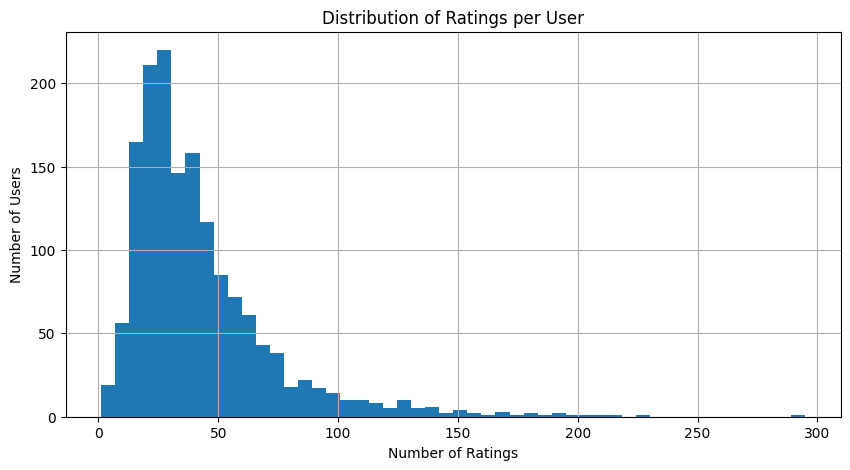

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

user_activity.hist(bins=50)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

* A substantial number of users have very few historical interactions. Since collaborative filtering relies on shared user behavior, recommendation quality is expected to deteriorate for these users due to insufficient preference information.

In [99]:
cold_users = user_activity[user_activity <= 5]

print("Number of cold-start users:", len(cold_users))

Number of cold-start users: 17


### Failure Analysis 2: Sparse Products
Hypothesis

Products with very few ratings are difficult to recommend.

In [100]:
product_activity = df_final.groupby("prod_id")["rating"].count()

product_activity.describe()

count    5689.000000
mean       11.476534
std        11.410025
min         5.000000
25%         6.000000
50%         8.000000
75%        13.000000
max       206.000000
Name: rating, dtype: float64

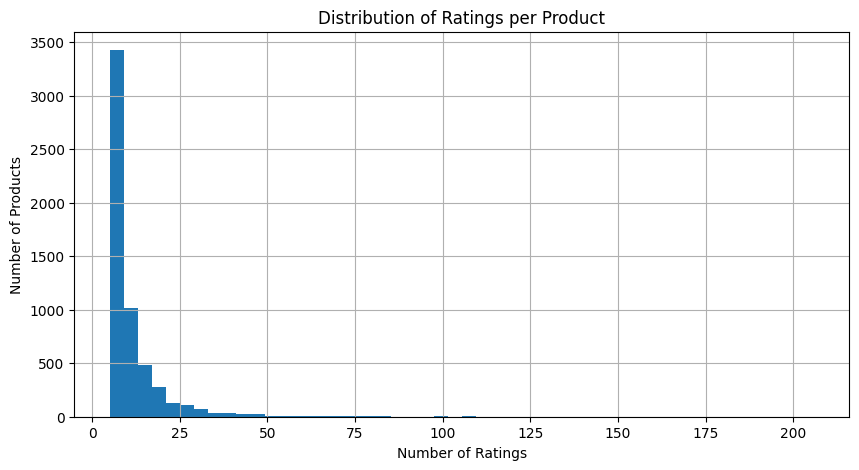

In [101]:
plt.figure(figsize=(10,5))

product_activity.hist(bins=50)

plt.title("Distribution of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")

plt.show()

* Sparse products suffer from limited interaction information, making it difficult for neighborhood-based methods and matrix factorization models to learn reliable latent representations.

In [102]:
sparse_products = product_activity[product_activity <= 5]

print("Number of sparse products:", len(sparse_products))

Number of sparse products: 1082


### Failure Analysis 3: Popularity Bias

This one is very important because it directly relates to Hybrid V2 failing.

In [103]:
top_products = (
    df_final["prod_id"]
    .value_counts()
    .head(20)
)

top_products

prod_id
B0088CJT4U    206
B003ES5ZUU    184
B000N99BBC    167
B007WTAJTO    164
B00829TIEK    149
B00829THK0    137
B008DWCRQW    137
B002R5AM7C    128
B004CLYEDC    118
B002SZEOLG    113
B00834SJNA    110
B004T9RR6I    109
B002V88HFE    106
B0034CL2ZI    106
B00834SJSK    101
B002WE6D44    100
B00829TIA4     99
B004CLYEFK     97
B009SYZ8OC     95
B0079UAT0A     92
Name: count, dtype: int64

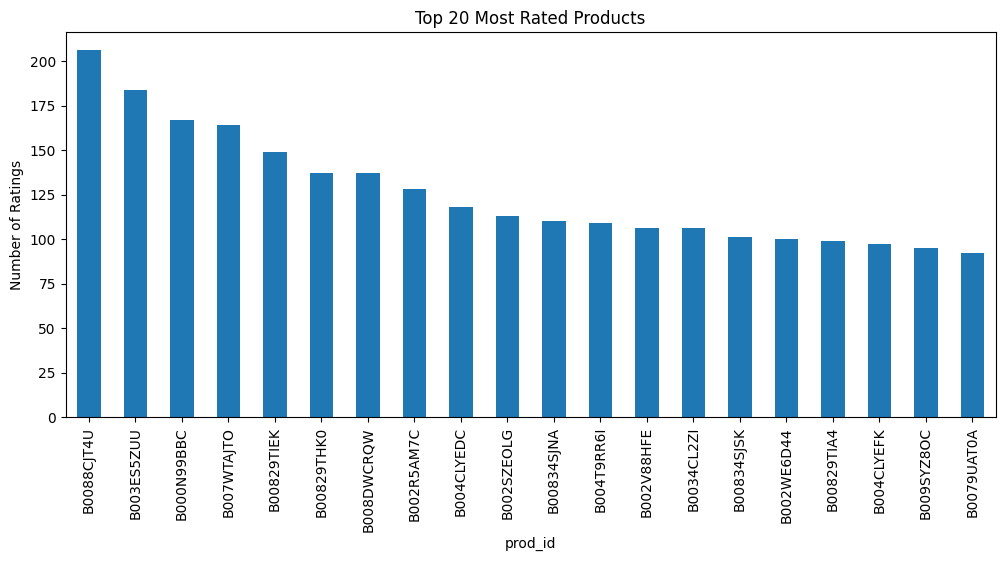

In [104]:
plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 20 Most Rated Products")
plt.ylabel("Number of Ratings")

plt.show()

* The interaction distribution is highly concentrated among a small subset of products. This popularity imbalance may bias recommendation models toward frequently rated products while reducing exposure to niche items.

### Failure Analysis 4: Rating Distribution

This helps explain why recommendation is difficult.

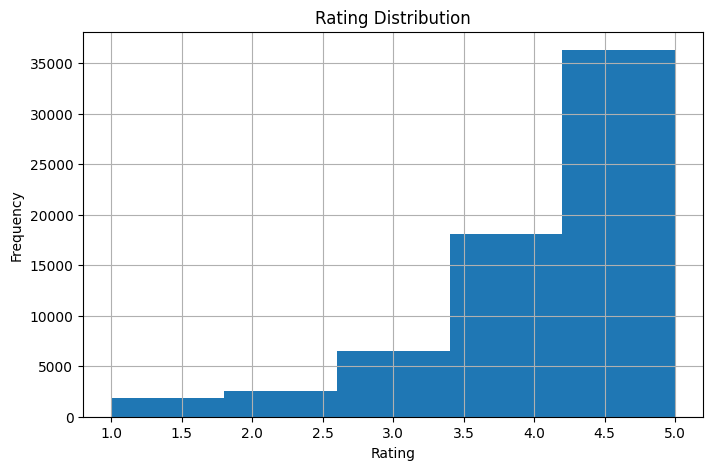

In [105]:
plt.figure(figsize=(8,5))

df_final["rating"].hist(bins=5)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

* The rating distribution is highly skewed toward positive feedback. Such imbalance makes it more difficult to distinguish between highly preferred and moderately preferred products.

### Failure Analysis 5 (Best One)

Compare Best and Worst Users

In [107]:
user_counts = (
    df_final
    .groupby("user_id")["rating"]
    .count()
    .sort_values()
)

user_counts.head()

user_id
A3DL29NLZ7SXXG    1
AP2NZAALUQKF5     1
A3MV1KKHX51FYT    1
A2BGZ52M908MJY    2
A16CVJUQOB6GIB    2
Name: rating, dtype: int64

In [108]:
user_counts.tail()

user_id
A25C2M3QF9G7OQ    203
A36K2N527TXXJN    212
A1ODOGXEYECQQ8    217
A3OXHLG6DIBRW8    230
ADLVFFE4VBT8      295
Name: rating, dtype: int64

In [112]:
svd_recommendations = get_recommendations(df_final, "A3DL29NLZ7SXXG", 5, svd_optimized)
ranking_products(svd_recommendations, final_rating)

,prod_id,rating_count,predicted_ratings,corrected_ratings
0,B00IVPU6AA,14,4.981770,4.714509
1,B00B4GGW5Q,14,4.979384,4.712123
2,B0017H4G0A,9,5.000000,4.666667
3,B0035FZ12O,7,4.990082,4.612117
4,B00HYAL84G,5,4.968285,4.521071


In [110]:
svd_recommendations = get_recommendations(df_final, "ADLVFFE4VBT8", 5, svd_optimized)
ranking_products(svd_recommendations, final_rating)

,prod_id,rating_count,predicted_ratings,corrected_ratings
0,B0033PRWSW,15,4.895243,4.637044
2,B0010Y414Q,11,4.922768,4.621257
1,B001BTCSI6,13,4.878404,4.601053
3,B000JV9LUK,10,4.893425,4.577197
4,B00AR95ESC,9,4.881177,4.547844


* Here I can see that no matter a good or bad users they receive the same good quality products based on rating count and average ratings

# 6. Ablation Study

In [123]:
ablation_results = pd.DataFrame({
    "Model":[
        "User-User CF",
        "User-User CF Tuned",
        "Item-Item CF",
        "Item-Item CF Tuned",
        "SVD",
        "SVD Tuned",
        "Hybrid_V1_best_alpha",
        "Hybrid_V2_best_alpha"
    ],
    "RMSE":[
        1.0012,
        0.9526,
        0.9950,
        0.9578,
        0.8882,
        0.8808,
        0.0,
        0.0
    ],
    "Precision@10":[
        0.855,
        0.847,
        0.838,
        0.839,
        0.853,
        0.854,
        0.878,
        0.861
    ],
    "Recall@10":[
        0.858,
        0.894,
        0.845,
        0.88,
        0.88,
        0.878,
        0.843,
        0.811,
    ],
    "F1@10":[
        0.856,
        0.87,
        0.841,
        0.859,
        0.866,
        0.866,
        0.860,
        0.835
    ]
})

ablation_results

,Model,RMSE,Precision@10,Recall@10,F1@10
0,User-User CF,1.0012,0.855,0.858,0.856
1,User-User CF Tuned,0.9526,0.847,0.894,0.870
2,Item-Item CF,0.9950,0.838,0.845,0.841
3,Item-Item CF Tuned,0.9578,0.839,0.880,0.859
4,SVD,0.8882,0.853,0.880,0.866
5,SVD Tuned,0.8808,0.854,0.878,0.866
6,Hybrid_V1_best_alpha,0.0000,0.878,0.843,0.860
7,Hybrid_V2_best_alpha,0.0000,0.861,0.811,0.835


* Hyperparameter tuning consistently improved performance across all recommendation methods. The largest improvement was observed for SVD, suggesting latent-factor models are highly sensitive to parameter selection. 

* However SVD has the best RMSE but not the best F1.

In [124]:
ablation_results_alpha_V1 = pd.DataFrame({
    "alpha":[
        "0.5",
        "0.6",
        "0.7",
        "0.8",
        "0.9"
    ],
    "Precision@10":[
        0.878197,
        0.874969,
        0.871153,
        0.868313,
        0.865297
    ],
    "Recall@10":[
        0.843136,
        0.842418,
        0.839546,
        0.837226,
        0.834854
    ],
    "F1@10":[
        0.860310,
        0.858385,
        0.855057,
        0.852486,
        0.849803
    ]
})

ablation_results_alpha_V1

,alpha,Precision@10,Recall@10,F1@10
0,0.5,0.878197,0.843136,0.860310
1,0.6,0.874969,0.842418,0.858385
2,0.7,0.871153,0.839546,0.855057
3,0.8,0.868313,0.837226,0.852486
4,0.9,0.865297,0.834854,0.849803


In [125]:
ablation_results_alpha_V2 = pd.DataFrame({
    "alpha":[
        "0.5",
        "0.6",
        "0.7",
        "0.8",
        "0.9"
    ],
    "Precision@10":[
        0.873750,
        0.871855,
        0.866545,
        0.864421,
        0.860738
    ],
    "Recall@10":[
        0.624643,
        0.698279,
        0.747296,
        0.788129,
        0.811624
    ],
    "F1@10":[
        0.728490,
        0.775473,
        0.802515,
        0.824514,
        0.835460
    ]
})

ablation_results_alpha_V2

,alpha,Precision@10,Recall@10,F1@10
0,0.5,0.873750,0.624643,0.728490
1,0.6,0.871855,0.698279,0.775473
2,0.7,0.866545,0.747296,0.802515
3,0.8,0.864421,0.788129,0.824514
4,0.9,0.860738,0.811624,0.835460


# 7. Benchmark Comparison

**Benchmark Comparison with the Amazon Recommendation Challenge**

This project was conducted under Track 1 (Kaggle Benchmark Deep Dive) and was inspired by the Kaggle competition:

[Recommended System for Amazon ICL 2021 Competition](https://www.kaggle.com/competitions/recommended-system-for-amazon-icl-2021/overview)

The competition focuses on building recommendation algorithms capable of predicting user preferences and generating relevant product suggestions from Amazon interaction data. Similar to industrial recommendation systems used in e-commerce platforms, the challenge involves addressing data sparsity, user preference modeling, and ranking optimization.

**Benchmark Approaches**

Modern recommendation systems commonly rely on collaborative filtering, matrix factorization, ranking models, and hybrid approaches. Matrix factorization methods such as Singular Value Decomposition (SVD) remain among the most widely used approaches because they can efficiently learn latent user-item relationships from sparse interaction matrices.

**Similarities to This Project**

The present project shares several characteristics with the benchmark challenge:

* Amazon product recommendation domain.
* Explicit user-product ratings.
* Collaborative filtering methodologies.
* Matrix factorization using SVD.
* Evaluation through recommendation quality metrics.

**Differences from the Benchmark**

Unlike many competition solutions that focus exclusively on maximizing predictive performance, this project emphasizes interpretability and controlled experimentation through:

* User-user collaborative filtering.
* Item-item collaborative filtering.
* Matrix factorization (SVD).
* Hyperparameter optimization.
* Failure analysis.
* Hybrid recommendation strategies.
* Benchmark Insights

The benchmark challenge demonstrates that recommendation quality depends not only on prediction accuracy but also on ranking effectiveness. This observation motivated the evaluation of Precision@10, Recall@10, and F1-score in addition to RMSE throughout this study. Community discussions on recommendation benchmarks frequently emphasize that top-N recommendation quality is often more informative than rating prediction error alone.

**Relationship to the Proposed Method**

The proposed Hybrid V1 recommender extends the benchmark baseline by combining:

Personalized SVD Predictions
+
Popularity-Based Product Ratings

This modification was designed to balance personalization and recommendation reliability while mitigating some limitations of pure matrix factorization models.

# 8. Discussion

Several important findings emerged from this study.

First, matrix factorization achieved the lowest RMSE among all evaluated models. The tuned SVD model obtained an RMSE of 0.8808, indicating superior rating prediction performance compared to neighborhood-based collaborative filtering methods.

However, recommendation quality measured through F1-score revealed a different picture. The tuned User-User Collaborative Filtering model achieved the highest F1-score (0.870), slightly outperforming the tuned SVD model (0.866). This result suggests that minimizing prediction error does not necessarily produce the best recommendation ranking.

To investigate whether recommendation quality could be improved further, a hybrid recommendation strategy was proposed. The Hybrid V1 model combined normalized SVD predictions with normalized product average ratings. Multiple weighting schemes were evaluated through a controlled ablation study.

The results showed that the best hybrid configuration occurred at α = 0.5, achieving:

* Precision = 0.878
* Recall = 0.843
* F1 = 0.860

Although the hybrid model did not surpass the best collaborative filtering baseline in terms of F1-score, it achieved the highest precision among all evaluated models. This indicates that the hybrid strategy generated more conservative but highly relevant recommendations.

A second hybrid version incorporated product interaction counts as an additional popularity signal. Contrary to expectations, performance decreased substantially. This outcome suggests that emphasizing highly popular products introduces popularity bias and reduces personalization.

Failure analysis further revealed several challenges inherent to recommendation systems:

* Cold-start users with limited interaction histories.
* Sparse products with few ratings.
* Highly imbalanced popularity distributions.
* Positively skewed rating distributions.

These findings are consistent with known limitations of collaborative filtering systems and provide opportunities for future improvement.

Overall, the results demonstrate that simple collaborative filtering approaches remain highly competitive and difficult to outperform despite their conceptual simplicity.

# 9. Reproducibility

To ensure reproducibility of the experiments, all models were trained and evaluated using fixed random seeds and a consistent train-test split.

**Hardware**
* Apple MacBook M4
* 16 GB RAM

**Software**
* Python 3.9
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-Learn
* Surprise
* Dataset Split

**The dataset was partitioned using:**

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

**Reproducibility Settings**

The optimized SVD model used:

SVD(
    n_epochs=20,
    lr_all=0.01,
    reg_all=0.2,
    random_state=1
)

The use of fixed random seeds ensures that all reported results can be reproduced consistently.

1. Execution Instructions
2. Install required Python packages.
3. Download the Amazon recommendation [dataset](https://drive.google.com/file/d/1XahZcR287ke7j48I7-oj0KzmmwSSvA3Y/view?usp=sharing).
4. Execute notebook cells sequentially.
5. Run all evaluation cells to reproduce metrics and figures.

### Final Results Table

| Model               | RMSE       | Precision@10 | Recall@10 | F1@10     |
| ------------------- | ---------- | ------------ | --------- | --------- |
| User-User CF        | 1.0012     | 0.855        | 0.858     | 0.856     |
| User-User CF Tuned  | 0.9526     | 0.847        | **0.894** | **0.870** |
| Item-Item CF        | 0.9950     | 0.838        | 0.845     | 0.841     |
| Item-Item CF Tuned  | 0.9578     | 0.839        | 0.880     | 0.859     |
| SVD                 | 0.8882     | 0.853        | 0.880     | 0.866     |
| SVD Tuned           | **0.8808** | 0.854        | 0.878     | 0.866     |
| Hybrid V1 (α = 0.5) | -          | **0.878**    | 0.843     | 0.860     |
| Hybrid V2 (α = 0.9) | -          | 0.861        | 0.812     | 0.835     |


# 9. Conclusion

This study investigated multiple recommendation strategies for Amazon product recommendation, including rank-based methods, user-user collaborative filtering, item-item collaborative filtering, matrix factorization, and hybrid recommendation approaches.

Experimental results demonstrated that hyperparameter tuning consistently improved model performance across all collaborative filtering methods. Among the evaluated models, the optimized SVD approach achieved the lowest RMSE (0.8808), while the optimized User-User Collaborative Filtering model achieved the highest F1-score (0.870), indicating superior recommendation relevance.

To further explore recommendation quality, a hybrid recommendation strategy was proposed by combining personalized SVD predictions with popularity-based product ratings. Through a controlled ablation study, the best hybrid configuration achieved a Precision@10 of 0.878, the highest precision among all evaluated models. However, the hybrid model did not surpass the best collaborative filtering baseline in overall F1-score, highlighting the trade-off between recommendation precision and recall.

Failure analysis revealed the impact of cold-start users, sparse products, popularity bias, and rating imbalance on recommendation performance. These findings provide valuable insights into the limitations of collaborative filtering systems in real-world environments.

Future work may explore Neural Collaborative Filtering, Graph Neural Networks, temporal recommendation models, and content-based hybrid architectures to further improve personalization and address cold-start challenges.

# Appendix

### Model Comparison (F1)

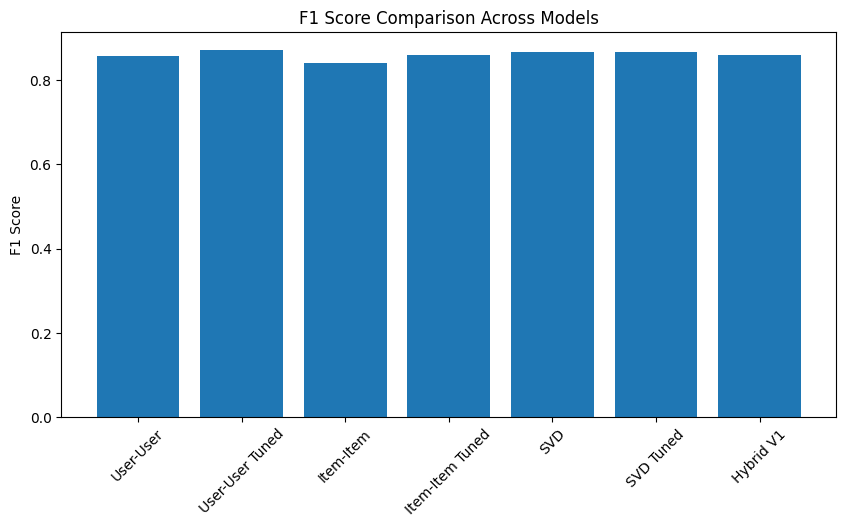

In [148]:
results = pd.DataFrame({
    "Model":[
        "User-User",
        "User-User Tuned",
        "Item-Item",
        "Item-Item Tuned",
        "SVD",
        "SVD Tuned",
        "Hybrid V1"
    ],
    "F1":[
        0.856,
        0.870,
        0.841,
        0.859,
        0.866,
        0.866,
        0.860
    ]
})

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["F1"])
plt.title("F1 Score Comparison Across Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)

plt.savefig('figures/F1_Score_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Hybrid Alpha Ablation

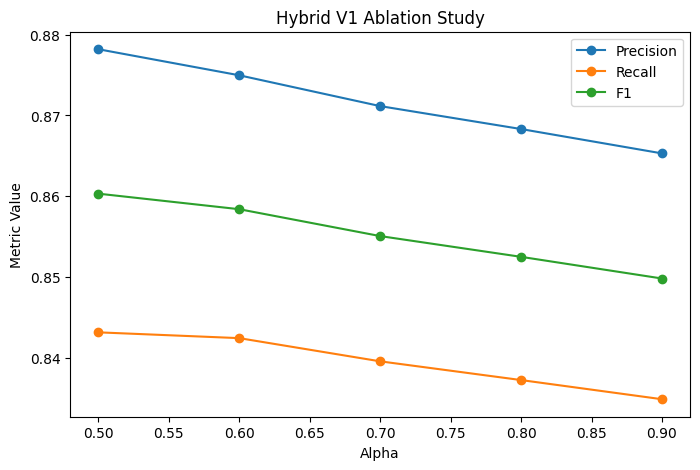

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    ablation_alpha["Alpha"],
    ablation_alpha["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    ablation_alpha["Alpha"],
    ablation_alpha["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    ablation_alpha["Alpha"],
    ablation_alpha["F1"],
    marker="o",
    label="F1"
)

plt.title("Hybrid V1 Ablation Study")
plt.xlabel("Alpha")
plt.ylabel("Metric Value")
plt.legend()

plt.savefig('figures/hybrid_v1_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

### User Activity Distribution

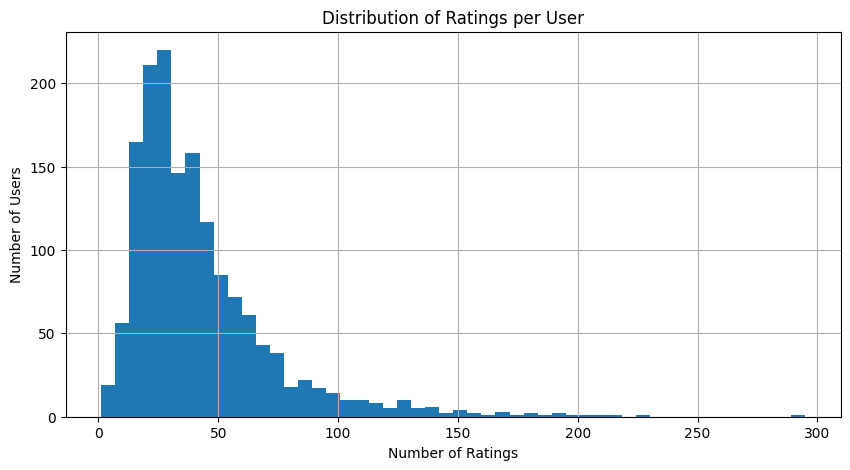

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

user_activity.hist(bins=50)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.savefig('figures/ratings_distribution_user.png', dpi=300, bbox_inches='tight')
plt.show()

### Product Popularity Distribution

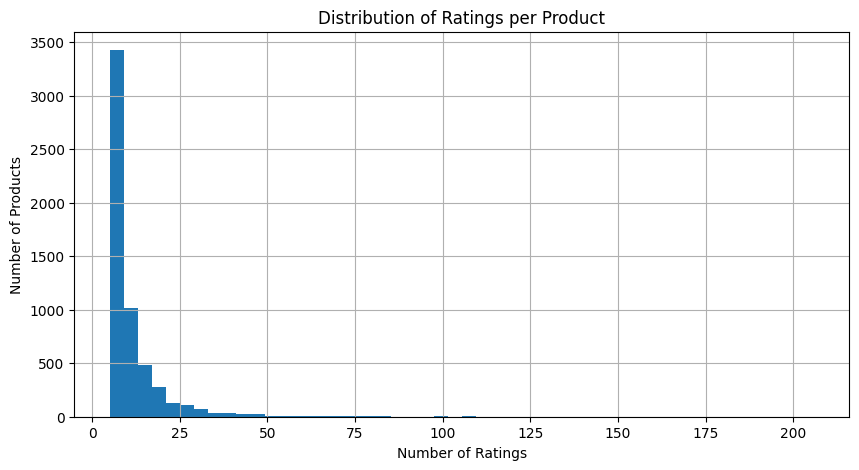

In [150]:
plt.figure(figsize=(10,5))

product_activity.hist(bins=50)

plt.title("Distribution of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")

plt.savefig('figures/ratings_distribution_product.png', dpi=300, bbox_inches='tight')
plt.show()

### Popularity Bias

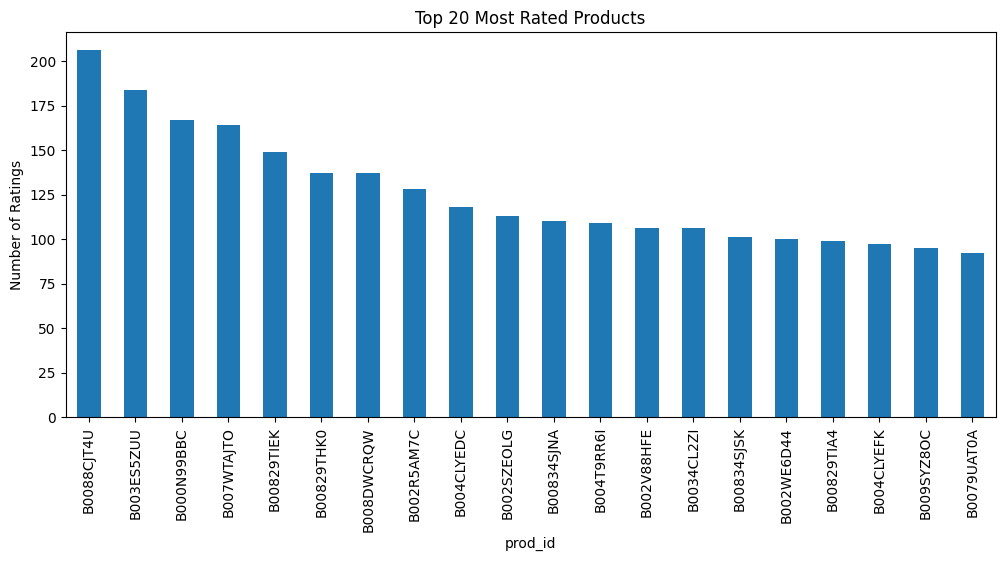

In [152]:
plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 20 Most Rated Products")
plt.ylabel("Number of Ratings")

plt.savefig('figures/Top 20 Most Rated Products.png', dpi=300, bbox_inches='tight')
plt.show()

### Side-by-Side RMSE Comparison

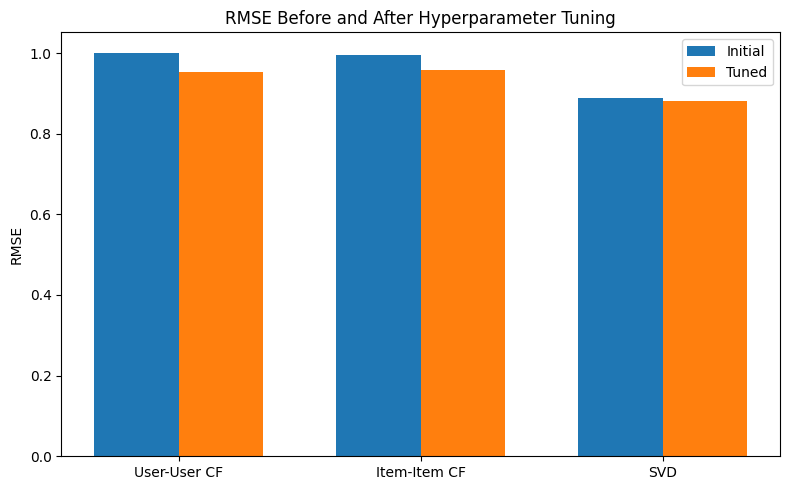

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": ["User-User CF", "Item-Item CF", "SVD"],
    "Initial RMSE": [1.0012, 0.9950, 0.8882],
    "Tuned RMSE": [0.9526, 0.9578, 0.8808]
})

x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    results["Initial RMSE"],
    width,
    label="Initial"
)

plt.bar(
    x + width/2,
    results["Tuned RMSE"],
    width,
    label="Tuned"
)

plt.xticks(x, results["Model"])
plt.ylabel("RMSE")
plt.title("RMSE Before and After Hyperparameter Tuning")
plt.legend()

plt.tight_layout()
plt.savefig('figures/RMSE_comparison.png', dpi=300, bbox_inches='tight')
plt.show()